In [ ]:
import pandas as pd
import os
from PIL import Image, ImageDraw
from pathlib import Path
import json
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as T

#to follow progres during training (train time)
from tqdm import tqdm

#for fast predictor (predict objects)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

#for mask R CNN model (predicts mask)
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.ops.boxes import torchvision
from torch.utils.data import DataLoader, Subset #for sample table
import cv2

# and for iou
from collections import namedtuple
import numpy as np

#for maP_mask
!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

#for randomness
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.3 MB/s eta 0:00:00


In [ ]:
#device cuda (compute unified device architecture) for google colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#pathway to drive file
from google.colab import drive
drive.mount('/content/drive')

#copy all to content, to avoid long loading time with drive mounting (once)
import shutil
if not os.path.exists('/content/Clouds-1000'):
    shutil.copytree('/content/drive/MyDrive/Clouds-1000', '/content/Clouds-1000')
else:
    #check for subfiles
    masks_ok = len(list(Path('/content/Clouds-1000/all_images_and_labels/masks').glob('*.json'))) > 100
    small_ok  = len(list(Path('/content/Clouds-1000/all_images_and_labels/images_small').glob('*.jpg'))) > 100

    if not masks_ok:
        shutil.copytree('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/masks',
                        '/content/Clouds-1000/all_images_and_labels/masks', dirs_exist_ok=True)
    if not small_ok:
        shutil.copytree('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/images_small',
                        '/content/Clouds-1000/all_images_and_labels/images_small', dirs_exist_ok=True)

print(f"Images: {len(list(Path('/content/Clouds-1000/all_images_and_labels/images_small').glob('*.jpg')))}")
print(f"Masks:  {len(list(Path('/content/Clouds-1000/all_images_and_labels/masks').glob('*.json')))}")

dir_all = Path('/content/Clouds-1000/all_images_and_labels')

#or directly load from drive
#dir_all = Path('/content/drive/MyDrive/Clouds-1000/all_images_and_labels')
image_path=dir_all/'images'
mask_path=dir_all/'masks'
#small_path = Path('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/images_small')
small_path = dir_all/'images_small'
image_files=list(sorted(small_path.glob('*.jpg')))
mask_files=list(sorted(mask_path.glob('*.json')))

Mounted at /content/drive
Images: 996
Masks:  996


In [ ]:
#training model: Mask R-CNN ResNet-50 FPN
model=torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
num_classes = 6  #number of classes, including background for training
in_features_box = model.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
#change only last layer
model.roi_heads.box_predictor =FastRCNNPredictor(in_features_box, num_classes)#replace model's head with new one (for number of classes in dataset)
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes) #add hidden layer as argument for maskRCNN

#prepare data for R CNN
# Define transformations (equal to ResNet18 baseline) & resize images for smaller data
transform = T.Compose([ #withoug T.Resize((224, 224)), as done already before loading
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), #for DataAugmentation
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
]) #mean and std for generalized ImageNet dataset for RGB values

#create Custom Dataset to organise data in boxes/polygons and labels/classes
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, transforms=None):
        self.df = df
        self.transform = transforms
        self.classes = ['Arvore', 'Estratocumuliformes', 'Cirriformes', 'Estratiformes', 'Cumuliformes']
        #i+1, to let all 5 classes count, and not confound with background
        self.class_to_idx = {c: i+1 for i, c in enumerate(self.classes)}

    def __len__(self):   #detect len for batches
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['images']).convert('RGB')
        orig_w, orig_h = 2592, 1944   #from presized images (small_path), so set up original sizes here
        with open(self.df.iloc[idx]['masks']) as f:
            data = json.load(f)

        #scale boxes to 224x224
        scale_x = 224 / orig_w
        scale_y = 224 / orig_h

        boxes, labels, masks = [], [], [] #masks tensor for maskRCNN
        for obj in data['objects']:
            polygon = obj['points']['exterior']
            x_coords = [p[0] for p in polygon]
            y_coords = [p[1] for p in polygon]

            #to avoid unvalid boxes
            x1, y1, x2, y2 = min(x_coords), min(y_coords), max(x_coords), max(y_coords)
            if x2 <= x1 or y2 <= y1:
              continue

            #create mask for mask RCNN
            mask=Image.new('L', (224,224), 0) #new image: grey (L), w/h: 224, fillingcolor:0 (no object)
            scaled_polygon=[(p[0]*scale_x, p[1]*scale_y) for p in polygon]
            ImageDraw.Draw(mask).polygon(scaled_polygon, fill=1) #color:1 shows objects in white
            masks.append(torch.tensor(np.array(mask), dtype=torch.uint8))
            boxes.append([x1*scale_x, y1*scale_y, x2*scale_x, y2*scale_y]) #apply scale on boxes
            labels.append(self.class_to_idx[obj['classTitle']])

        #filter for empty boxes
        if len(boxes) == 0:
          boxes = [[0, 0, 1, 1]]
          labels = [0]
          masks = [torch.zeros((224, 224), dtype=torch.uint8)]

        if random.random() < 0.5: #apply flip on all 3 categories
          img = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
          boxes = [[224 - x2, y1, 224 - x1, y2] for x1, y1, x2, y2 in boxes]
          masks=[torch.flip(m, dims=[1]) for m in masks]

        target = {}
        target["boxes"] = torch.tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.tensor(labels, dtype=torch.int64)
        target['masks']=torch.stack(masks)

        if self.transform is not None:
            img = self.transform(img)

        return img, target



In [ ]:
#print(model)#.roi_heads.mask_predictor) #get number of hidden layers

In [ ]:
df=pd.DataFrame({'images': image_files, 'masks': mask_files})
# split into train, val, test sets: train_size=0.7, test_size=0.15 * 2
train_df, rest_df=train_test_split(df, test_size=0.25, random_state=42) #70% train
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42) #je 20%

#check size
print(f"Set sizes:\nTrain:\t{len(train_df)}")
print(f"Val:\t{len(val_df)}")
print(f"Test:\t{len(test_df)}")

#load datasets
train_ds = CustomDataset(train_df, transforms=transform)
val_ds   = CustomDataset(val_df,   transforms=transform)
test_ds=CustomDataset(test_df, transforms=transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader=DataLoader(test_ds, batch_size=8, shuffle=True, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))

Set sizes:
Train:	747
Val:	124
Test:	125


In [ ]:
##implement early stopping
class EarlyStopping:
  def __init__ (self, patience=5, min_delta=0.01):
    self.patience=patience #wait on how many epochs
    self.min_delta=min_delta #smallest amount of improvement
    self.counter=0
    self.best_map=0.0

  def check(self, current_map, model, save_path):
    if current_map > self.best_map + self.min_delta:
      self.best_map=current_map
      self.counter=0
      torch.save(model.state_dict(), save_path)
      print(f'Improvement - maP: {current_map:.4f}')
      return False #continue
    else:
      self.counter+=1
      print(f'no further improvement ({self.counter}/{self.patience})')
      if self.counter >= self.patience:
        print('Early Stopping')
        return True # stop
      return False

In [ ]:
####ONLY when new training needed:
early_stopping=EarlyStopping(patience=5, min_delta=0.001)

model.to(device)
#hidden layer einfrieren: backbone layer 1 & 2
for name, param in model.backbone.body.named_parameters():
  if 'layer1' in name or 'layer2' in name:
    param.requires_grad=False

# Set up the optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=0.0005) #change to paper value: lr=0.01
num_epochs = 20
#lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5) #gamma 0.1 very aggressive-> to 0.5
#2nd lr scheduler variation (smoother decay):
lr_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs,eta_min=1e-6 )
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    # Training loop
    #with loading bar
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        # Backward pass
        losses.backward()
        optimizer.step()
        train_loss += losses.item()
    # Update learning rate
    lr_scheduler.step()

    #evaluate training (without gradient calculation, only prediction: no_grad)
    model.eval()
    ious=[]
    map_mask=MeanAveragePrecision(iou_type='segm') #use mask in iou and maP evaluation
    with torch.no_grad():
      for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
        images=list(img.to(device) for img in images)
        prediction=model(images) #forward calculation through call

        for pred, target in zip(prediction, targets):
          preds_boxes=pred['boxes'].cpu()
          true_boxes=target['boxes'].cpu()

          if len(preds_boxes)==0 or len(true_boxes)==0: #jump over empty boxes
            continue
          iou_matrix=box_iou(preds_boxes, true_boxes)
          best_iou=iou_matrix.max(dim=1).values #choose best predicition for every original (ground truth) box
          ious.extend(best_iou.tolist())

        #for maP_mask change to cpu (not gpu compatible)
        true_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        preds_cpu = [{'boxes': p['boxes'].cpu(),'scores': p['scores'].cpu(),
                      'labels': p['labels'].cpu(),
                      'masks': (p['masks'].cpu() > 0.5).squeeze(1)}  #change from floatto binary
                      for p in prediction]
        map_mask.update(preds_cpu, true_cpu)
    mean_iou=sum(ious)/len(ious)
    result=map_mask.compute()
    val_map=result['map'].item()

    print(f'Epoch: {epoch + 1}, Loss: {train_loss / len(train_loader)}')

    #early stopping
    if early_stopping.check(val_map, model, '/content/drive/MyDrive/best_model.pth'):
      break

print("Training complete!")
#load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model.pth'))
print(f"Finished with best model: mAP={early_stopping.best_map:.4f}")

Epoch 1/20: 100%|██████████| 94/94 [02:55<00:00,  1.87s/it]


Epoch: 1, Loss: 0.8954296448129289
Improvement - maP: 0.2290


Epoch 2/20: 100%|██████████| 94/94 [02:55<00:00,  1.87s/it]


Epoch: 2, Loss: 0.8537600899630404
Improvement - maP: 0.2432


Epoch 3/20: 100%|██████████| 94/94 [02:55<00:00,  1.87s/it]


...

Epoch: 16, Loss: 0.4985370895964034
no further improvement (3/5)


Epoch 17/20: 100%|██████████| 94/94 [02:59<00:00,  1.91s/it]


Epoch: 17, Loss: 0.4879412768369025
no further improvement (4/5)


Epoch 18/20: 100%|██████████| 94/94 [02:59<00:00,  1.91s/it]


Epoch: 18, Loss: 0.4736585372940023
no further improvement (5/5)
Early Stopping
Training complete!
Finished with best model: mAP=0.3158


In [ ]:
#####IF already trained and model saved:
model.to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model.pth', map_location=device))
model.eval()

In [ ]:
#print(f'Mean Average Prediction (maP score): {result}')
print(f'Mean Average Prediction (maP score): {result['map']:.4f}')
print(f'Mean IoU: {mean_iou}')

Mean Average Prediction (maP score): 0.3140
Mean IoU: 0.41848719064731954


In [ ]:
#train:80
train_df, rest_df=train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42)
#load datasets
train_ds = CustomDataset(train_df, transforms=transform)
val_ds   = CustomDataset(val_df,   transforms=transform)
test_ds=CustomDataset(test_df, transforms=transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader=DataLoader(test_ds, batch_size=8, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))

#check how much training data is needed for success (with map)
sample_size=[50, 100, 300, 500, len(train_df)]
map_results={}
for s in sample_size:
  print(f'Amount of Training Data: {s}')
  set_seed(42)
  sample_ds=Subset(train_ds, list(range(s)))
  sample_loader=DataLoader(sample_ds,batch_size=8, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

  #training model: Mask R-CNN ResNet-50 FPN
  model_s=torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
  num_classes = 6  #number of classes, including background for training
  in_features_box = model_s.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
  in_features_mask = model_s.roi_heads.mask_predictor.conv5_mask.in_channels
  #change only last layer
  model_s.roi_heads.box_predictor =FastRCNNPredictor(in_features_box, num_classes)#replace model's head with new one (for number of classes in dataset)
  model_s.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes) #add hidden layer as argument for maskRCNN

  #hidden layer einfrieren: backbone layer 1 & 2
  for name, param in model_s.backbone.body.named_parameters():
    if 'layer1' in name or 'layer2' in name:
      param.requires_grad=False

  model_s.to(device)
  num_epochs = 20
  params = [p for p in model_s.parameters() if p.requires_grad]
  optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=0.0005) #lr from 0.005 to 0.01
  lr_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs,eta_min=1e-6 )
  for epoch in range(num_epochs):
      model_s.train() #no saving/later use of trainloss necessary
      # Training loop
      for images, targets in tqdm(sample_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
          images = list(image.to(device) for image in images)
          targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
          optimizer.zero_grad()
          loss_dict = model_s(images, targets)
          losses = sum(loss_dict.values())
          losses.backward()
          optimizer.step()

      # Update learning rate (when num_epochs>10)
      lr_scheduler.step()
      print(f'Epoch: {epoch + 1}')
      print("Training complete!")

  #evaluate training (without gradient calculation, only prediction: no_grad)
  model_s.eval()
  map_metric=MeanAveragePrecision(iou_type='segm')
  with torch.no_grad():
    for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
        images=list(img.to(device) for img in images)
        preds  = model_s(images)
        map_metric.update([{'boxes': p['boxes'].cpu(),'scores': p['scores'].cpu(),
                            'labels': p['labels'].cpu(),
                            'masks': (p['masks'].cpu() > 0.5).squeeze(1)}  #change from float to binary
                           for p in preds],
                            [{k: v.cpu() for k, v in t.items()} for t in targets]
                          )
  result=map_metric.compute()
  map_results[s] = result['map'].item()
  print(f'Amount={s}: maP = {map_results[s]:.4f}')

Amount of Training Data: 50


Epoch 1/20: 100%|██████████| 7/7 [00:11<00:00,  1.62s/it]


Epoch: 1
Training complete!


Epoch 2/20: 100%|██████████| 7/7 [00:09<00:00,  1.35s/it]


Epoch: 2
Training complete!


...

Epoch: 18
Training complete!


Epoch 19/20: 100%|██████████| 100/100 [03:09<00:00,  1.89s/it]


Epoch: 19
Training complete!


Epoch 20/20: 100%|██████████| 100/100 [03:08<00:00,  1.89s/it]


Epoch: 20
Training complete!
Amount=796: maP = 0.3102


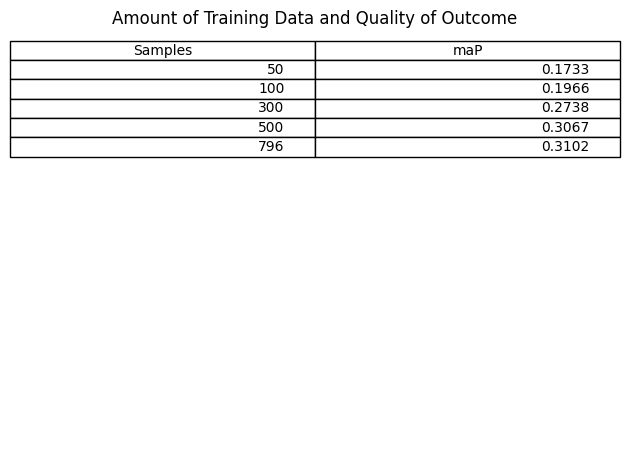

In [ ]:
#print table
import matplotlib.pyplot as plt

table_data=[]
for s,m in map_results.items():
  table_data.append([s, f'{m:.4f}'])

fig, ax = plt.subplots() #figsize=(10, 7)
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=['Samples', 'maP'], loc='upper center')
ax.set_title('Amount of Training Data and Quality of Outcome') #fontsize=12, fontweight='bold'
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Clouds-1000/Performance_SampleSize_table_final.jpeg')
#plt.show()

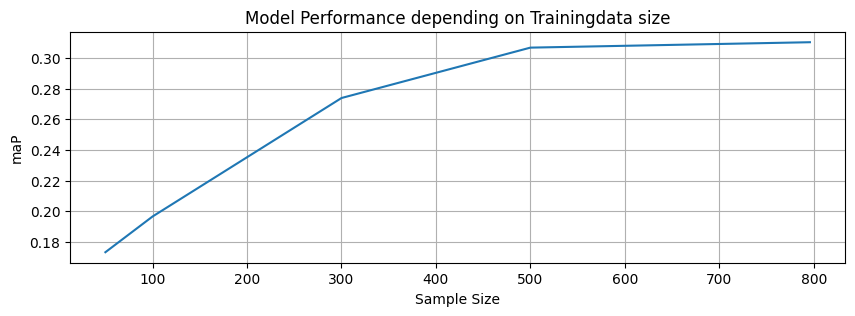

In [ ]:
#visualitze table
plt.figure(figsize=(10,3))
plt.plot(list(map_results.keys()), list(map_results.values()))
plt.title('Model Performance depending on Trainingdata size')
plt.xlabel('Sample Size')
plt.ylabel('maP')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Clouds-1000/Performance_SampleSize_final.jpeg')
#plt.show()